# PHASE 07: SIMPLECNN HYBRID STRATEGY STUDY

Phase 05 đã test riêng **sampler/data-level imbalance handling**.  
Phase 06 đã test riêng **loss-level imbalance handling**.

Phase 07 kiểm tra câu hỏi quan trọng:

> Nếu lấy chiến lược tốt nhất của Phase 05 kết hợp với loss tốt nhất của Phase 06, model SimpleCNN hybrid có tốt hơn từng hướng đơn lẻ không?

Phase này vẫn chỉ dùng **SimpleCNN**. MobileNetV2/EfficientNet-B0 chỉ bắt đầu từ Phase 08.

# 01. Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

try:
    from IPython.display import display
except ImportError:
    display = print

def bootstrap_project_dir() -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidates = [root, root / 'plan']
        for candidate in candidates:
            if (candidate / 'src').exists():
                if str(candidate) not in sys.path:
                    sys.path.append(str(candidate))
                from src.paths import find_project_dir
                return find_project_dir(candidate)
    raise FileNotFoundError('Không tìm thấy thư mục project plan chứa src/. Hãy chạy notebook từ repo hoặc thư mục plan.')


PROJECT_DIR = bootstrap_project_dir()

from src.data import (
    ProjectPaths,
    ensure_directories,
    load_metadata,
    create_imbalanced_subset,
    create_stratified_subset,
    create_hybrid_resampled_dataset,
    get_class_counts,
    get_num_classes,
    compute_inverse_frequency_weights,
    build_data_loader,
    build_weighted_sampler,
)
from src.models import get_simple_cnn
from src.train import FocalLoss, effective_number_class_weights, train_model, evaluate_model
from src.utils import (
    set_seed,
    get_device,
    get_pin_memory,
    get_num_workers,
    get_basic_transform,
    get_light_augmentation_transform,
    dataframe_to_markdown_safe,
    write_text_report,
)
from src.visualization import set_publication_style, annotate_bars, plot_confusion_heatmap

SEED = 42
set_seed(SEED)
set_publication_style()

DEVICE = get_device()
print(f'Thiết bị sử dụng: {DEVICE}')

PATHS = ProjectPaths(PROJECT_DIR)
BASE_DIR = PATHS.base_dir
METADATA_DIR = PATHS.metadata_dir
RESULTS_ROOT = PROJECT_DIR / 'results'
RESULTS_DIR = PATHS.results_dir('07_simplecnn_hybrid_strategy_study')
REPORTS_DIR = PATHS.reports_dir('07_simplecnn_hybrid_strategy_study')
PHASE07_DIR = RESULTS_DIR / 'phase_07_simplecnn_hybrid_strategy'
PHASE07_TABLE_DIR = PHASE07_DIR / 'tables'
PHASE07_FIGURE_DIR = PHASE07_DIR / 'figures'
PHASE07_REPORT_DIR = PHASE07_DIR / 'reports'
PHASE07_MODEL_DIR = PHASE07_DIR / 'saved_models'

ensure_directories(
    RESULTS_DIR,
    REPORTS_DIR,
    PHASE07_DIR,
    PHASE07_TABLE_DIR,
    PHASE07_FIGURE_DIR,
    PHASE07_REPORT_DIR,
    PHASE07_MODEL_DIR,
)

# Giữ cấu hình giống Phase 05/06 để so sánh công bằng.
USE_SUBSET = True
SUBSET_MAJORITY_FRACTION = 0.20
SUBSET_MINORITY_FRACTION = 0.45
SUBSET_THRESHOLD = 500
SUBSET_MIN_SAMPLES = 40
VAL_TEST_SUBSET_FRACTION = 0.30
VAL_TEST_MIN_SAMPLES = 8

IMAGE_SIZE = 128
NUM_WORKERS = get_num_workers(DEVICE, notebook_safe=True)
PIN_MEMORY = get_pin_memory(DEVICE)
FORCE_TRAIN = True
EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
BATCH_SIZE = 64
LR = 1e-3
FOCAL_GAMMA = 2.0
CB_BETA = 0.999

print(f'Output directory: {PHASE07_DIR}')


Thiết bị sử dụng: mps
Output directory: <PROJECT_DIR>/results/07_simplecnn_hybrid_strategy_study/phase_07_simplecnn_hybrid_strategy


# 02. Load winners từ Phase 05 và Phase 06

Phase 07 không đoán thủ công. Notebook đọc bảng kết quả đã lưu và tự chọn winner theo `Macro F1`.

In [2]:
phase05_path = RESULTS_ROOT / '05_imbalance_analysis' / 'phase_05_analysis' / 'tables' / 'ablation_study_summary.csv'
phase06_path = RESULTS_ROOT / '06_loss_function_study' / 'phase_06_loss_study' / 'tables' / 'loss_function_comparison.csv'

if not phase05_path.exists():
    raise FileNotFoundError(f'Không tìm thấy Phase 05 results: {phase05_path}')
if not phase06_path.exists():
    raise FileNotFoundError(f'Không tìm thấy Phase 06 results: {phase06_path}')

phase05_df = pd.read_csv(phase05_path)
phase06_df = pd.read_csv(phase06_path)

if 'Worst-class Recall' in phase05_df.columns and 'Worst Recall' not in phase05_df.columns:
    phase05_df = phase05_df.rename(columns={'Worst-class Recall': 'Worst Recall'})
if 'Worst-class Recall' in phase06_df.columns and 'Worst Recall' not in phase06_df.columns:
    phase06_df = phase06_df.rename(columns={'Worst-class Recall': 'Worst Recall'})

phase05_winner = phase05_df.sort_values('Macro F1', ascending=False).iloc[0]
phase06_winner = phase06_df.sort_values('Macro F1', ascending=False).iloc[0]

print('Phase 05 winner:', phase05_winner['Experiment'])
print('Phase 06 winner:', phase06_winner['Experiment'])

display(phase05_df.sort_values('Macro F1', ascending=False))
display(phase06_df.sort_values('Macro F1', ascending=False))


Phase 05 winner: sampler_aug_earlystop
Phase 06 winner: class_balanced_loss


,Experiment,Accuracy,Macro F1,Minority Recall,Worst Recall
3,sampler_aug_earlystop,0.833127,0.812635,0.898826,0.522727
1,weighted_sampler,0.831891,0.803676,0.884843,0.415094
0,baseline,0.849197,0.798896,0.715883,0.277778
4,hybrid_resampling,0.816440,0.779941,0.882188,0.438596
2,sampler_light_aug,0.795426,0.770671,0.852641,0.421053


,Experiment,Accuracy,Macro Precision,Macro Recall,Macro F1,Minority Recall,Worst Recall
0,class_balanced_loss,0.832509,0.775059,0.845858,0.795935,0.886295,0.452830
1,focal_loss,0.834363,0.818876,0.799888,0.795813,0.807267,0.366667
2,ce_baseline,0.836218,0.798178,0.809228,0.783917,0.818854,0.266667
3,weighted_ce,0.759580,0.713443,0.759937,0.710292,0.793740,0.350877


# 03. Load dataset giống Phase 05/06

Để so sánh công bằng, Phase 07 dùng cùng subset strategy, image size, split và SimpleCNN architecture như Phase 05/06.

In [3]:
train_df_raw, val_df_raw, test_df_raw, class_map_df = load_metadata(METADATA_DIR)
NUM_CLASSES = get_num_classes(class_map_df=class_map_df)
class_names_list = class_map_df.sort_values('class_id')['class_name'].tolist()

if USE_SUBSET:
    train_df = create_imbalanced_subset(
        train_df_raw,
        majority_fraction=SUBSET_MAJORITY_FRACTION,
        minority_fraction=SUBSET_MINORITY_FRACTION,
        threshold=SUBSET_THRESHOLD,
        min_samples=SUBSET_MIN_SAMPLES,
        seed=SEED,
    )
    val_df = create_stratified_subset(
        val_df_raw,
        fraction=VAL_TEST_SUBSET_FRACTION,
        min_samples=VAL_TEST_MIN_SAMPLES,
        seed=SEED,
    )
    test_df = create_stratified_subset(
        test_df_raw,
        fraction=VAL_TEST_SUBSET_FRACTION,
        min_samples=VAL_TEST_MIN_SAMPLES,
        seed=SEED,
    )
else:
    train_df = train_df_raw.copy()
    val_df = val_df_raw.copy()
    test_df = test_df_raw.copy()

train_counts = get_class_counts(train_df)
minority_threshold = train_counts.quantile(0.25)
minority_ids = train_counts[train_counts <= minority_threshold].index.tolist()
imbalance_ratio = train_counts.max() / train_counts.min()

print(f'Train={len(train_df):,} | Val={len(val_df):,} | Test={len(test_df):,}')
print(f'Num classes={NUM_CLASSES}')
print(f'Imbalance ratio={imbalance_ratio:.2f}')
print('Minority class IDs:', minority_ids)


Train=9,383 | Val=1,617 | Test=1,618
Num classes=38
Imbalance ratio=16.31
Minority class IDs: [0, 2, 6, 9, 14, 17, 22, 23, 31, 36]


# 04. Build hybrid configuration

Hybrid strategy = winner Phase 05 + winner Phase 06.  
Ví dụ: `sampler_aug_earlystop + class_balanced_loss`.

In [4]:
baseline_transform = get_basic_transform(IMAGE_SIZE)
light_aug_transform = get_light_augmentation_transform(IMAGE_SIZE)
val_test_transform = baseline_transform

sampler_weights = compute_inverse_frequency_weights(train_counts, num_classes=NUM_CLASSES)
HYBRID_TARGET_SIZE = int(train_counts.median())
hybrid_train_df = create_hybrid_resampled_dataset(train_df, target_size=HYBRID_TARGET_SIZE, seed=SEED)

PHASE05_STRATEGIES = {
    'baseline': {
        'train_df': train_df,
        'train_transform': baseline_transform,
        'use_sampler': False,
        'use_early_stopping': False,
        'description': 'No sampler, no augmentation, no early stopping',
    },
    'weighted_sampler': {
        'train_df': train_df,
        'train_transform': baseline_transform,
        'use_sampler': True,
        'use_early_stopping': False,
        'description': 'WeightedRandomSampler only',
    },
    'sampler_light_aug': {
        'train_df': train_df,
        'train_transform': light_aug_transform,
        'use_sampler': True,
        'use_early_stopping': False,
        'description': 'WeightedRandomSampler + Light Augmentation',
    },
    'sampler_aug_earlystop': {
        'train_df': train_df,
        'train_transform': light_aug_transform,
        'use_sampler': True,
        'use_early_stopping': True,
        'description': 'WeightedRandomSampler + Light Augmentation + EarlyStopping',
    },
    'hybrid_resampling': {
        'train_df': hybrid_train_df,
        'train_transform': light_aug_transform,
        'use_sampler': False,
        'use_early_stopping': True,
        'description': 'Hybrid resampling + Light Augmentation + EarlyStopping',
    },
}

phase05_winner_name = phase05_winner['Experiment']
phase06_winner_name = phase06_winner['Experiment']

if phase05_winner_name not in PHASE05_STRATEGIES:
    raise ValueError(f'Unknown Phase 05 winner: {phase05_winner_name}')

hybrid_strategy = PHASE05_STRATEGIES[phase05_winner_name]
hybrid_name = f"hybrid_{phase05_winner_name}_{phase06_winner_name}"

hybrid_design_df = pd.DataFrame([{
    'Hybrid Experiment': hybrid_name,
    'Phase 05 Component': phase05_winner_name,
    'Phase 05 Description': hybrid_strategy['description'],
    'Phase 06 Component': phase06_winner_name,
    'Train Size': len(hybrid_strategy['train_df']),
    'Use Sampler': hybrid_strategy['use_sampler'],
    'Use EarlyStopping': hybrid_strategy['use_early_stopping'],
}])

hybrid_design_df.to_csv(PHASE07_TABLE_DIR / 'phase07_hybrid_design.csv', index=False)
display(hybrid_design_df)


,Hybrid Experiment,Phase 05 Component,Phase 05 Description,Phase 06 Component,Train Size,Use Sampler,Use EarlyStopping
0,hybrid_sampler_aug_earlystop_class_balanced_loss,sampler_aug_earlystop,WeightedRandomSampler + Light Augmentation + E...,class_balanced_loss,9383,True,True


# 05. Build loss function

Loss winner từ Phase 06 được tái tạo bằng đúng công thức đã dùng ở Phase 06.

In [5]:
inverse_weights = compute_inverse_frequency_weights(train_counts, num_classes=NUM_CLASSES)
class_balanced_weights = effective_number_class_weights(
    class_counts=train_counts,
    num_classes=NUM_CLASSES,
    beta=CB_BETA,
)


def build_selected_loss(loss_name):
    inverse_weight_tensor = torch.FloatTensor(inverse_weights).to(DEVICE)
    cb_weight_tensor = torch.FloatTensor(class_balanced_weights).to(DEVICE)

    if loss_name == 'ce_baseline':
        return nn.CrossEntropyLoss()
    if loss_name == 'weighted_ce':
        return nn.CrossEntropyLoss(weight=inverse_weight_tensor)
    if loss_name == 'focal_loss':
        return FocalLoss(gamma=FOCAL_GAMMA, weight=None)
    if loss_name == 'class_balanced_loss':
        return nn.CrossEntropyLoss(weight=cb_weight_tensor)
    raise ValueError(f'Unknown loss function: {loss_name}')

criterion = build_selected_loss(phase06_winner_name)
print('Selected loss:', phase06_winner_name)
print(criterion)


Selected loss: class_balanced_loss
CrossEntropyLoss()


# 06. DataLoader cho hybrid experiment

Nếu winner Phase 05 dùng sampler thì sampler chỉ áp dụng trên train loader. Validation/test không bao giờ bị resampling.

In [6]:
def build_hybrid_loaders(strategy):
    train_data = strategy['train_df']
    sampler = None
    if strategy['use_sampler']:
        sampler = build_weighted_sampler(train_data, sampler_weights, replacement=True)

    train_loader = build_data_loader(
        df=train_data,
        base_dir=BASE_DIR,
        dataset_name='color',
        transform=strategy['train_transform'],
        batch_size=BATCH_SIZE,
        shuffle=not strategy['use_sampler'],
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = build_data_loader(
        df=val_df,
        base_dir=BASE_DIR,
        dataset_name='color',
        transform=val_test_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    test_loader = build_data_loader(
        df=test_df,
        base_dir=BASE_DIR,
        dataset_name='color',
        transform=val_test_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_hybrid_loaders(hybrid_strategy)
print('Hybrid loaders ready.')


Hybrid loaders ready.


# 07. Train hybrid SimpleCNN

Đây là experiment mới của Phase 07. Nó kiểm tra liệu hai hướng tốt nhất ở Phase 05 và Phase 06 có bổ trợ nhau hay không.

In [7]:
set_seed(SEED)
model = get_simple_cnn(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
save_path = PHASE07_MODEL_DIR / f'{hybrid_name}_{IMAGE_SIZE}px_best.pth'

print('\n' + '=' * 80)
print('HYBRID SIMPLECNN EXPERIMENT')
print(f'Experiment: {hybrid_name}')
print(f'Phase 05 component: {phase05_winner_name}')
print(f'Phase 06 component: {phase06_winner_name}')
print('=' * 80)

if (not FORCE_TRAIN) and save_path.exists():
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    history = None
    print(f'Loaded checkpoint: {save_path}')
else:
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=EPOCHS,
        device=DEVICE,
        save_path=save_path,
        patience=EARLY_STOPPING_PATIENCE,
        use_early_stopping=hybrid_strategy['use_early_stopping'],
    )
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    pd.DataFrame(history).to_csv(PHASE07_TABLE_DIR / f'{hybrid_name}_training_history.csv', index=False)

hybrid_result = evaluate_model(model, test_loader, DEVICE, num_classes=NUM_CLASSES)
print(f"[RESULT] Acc={hybrid_result['accuracy']:.4f} | Macro F1={hybrid_result['macro_f1']:.4f}")

pd.DataFrame({
    'true_label': hybrid_result['labels'],
    'predicted_label': hybrid_result['preds'],
}).to_csv(PHASE07_TABLE_DIR / f'{hybrid_name}_predictions.csv', index=False)



HYBRID SIMPLECNN EXPERIMENT
Experiment: hybrid_sampler_aug_earlystop_class_balanced_loss
Phase 05 component: sampler_aug_earlystop
Phase 06 component: class_balanced_loss
Epoch 01/15 | Train Loss: 2.8620 | Val Loss: 2.5990 | Val Acc: 0.1540 | Val Macro F1: 0.1462
Epoch 02/15 | Train Loss: 1.9655 | Val Loss: 2.0390 | Val Acc: 0.2789 | Val Macro F1: 0.3092
Epoch 03/15 | Train Loss: 1.5809 | Val Loss: 1.8551 | Val Acc: 0.3408 | Val Macro F1: 0.3712
Epoch 04/15 | Train Loss: 1.3686 | Val Loss: 1.4679 | Val Acc: 0.4613 | Val Macro F1: 0.4957
Epoch 05/15 | Train Loss: 1.1648 | Val Loss: 1.1873 | Val Acc: 0.5387 | Val Macro F1: 0.5560
Epoch 06/15 | Train Loss: 1.0316 | Val Loss: 1.1038 | Val Acc: 0.5986 | Val Macro F1: 0.5820
Epoch 07/15 | Train Loss: 0.9750 | Val Loss: 1.2711 | Val Acc: 0.5139 | Val Macro F1: 0.5449
Epoch 08/15 | Train Loss: 0.8418 | Val Loss: 0.9645 | Val Acc: 0.6092 | Val Macro F1: 0.6377
Epoch 09/15 | Train Loss: 0.7927 | Val Loss: 0.9254 | Val Acc: 0.6419 | Val Macro F1

# 08. Per-class metrics và confusion matrix

,Experiment,Class_ID,Class,Train Sample Count,Is Minority,Precision,Recall,F1-score
0,hybrid_sampler_aug_earlystop_class_balanced_loss,0,Apple___Apple_scab,100,True,0.523810,0.611111,0.564103
1,hybrid_sampler_aug_earlystop_class_balanced_loss,1,Apple___Black_rot,223,False,0.888889,0.444444,0.592593
2,hybrid_sampler_aug_earlystop_class_balanced_loss,2,Apple___Cedar_apple_rust,99,True,0.727273,1.000000,0.842105
3,hybrid_sampler_aug_earlystop_class_balanced_loss,3,Apple___healthy,263,False,0.851852,0.469388,0.605263
4,hybrid_sampler_aug_earlystop_class_balanced_loss,4,Blueberry___healthy,240,False,0.953488,0.911111,0.931818
5,hybrid_sampler_aug_earlystop_class_balanced_loss,5,Cherry_(including_sour)___Powdery_mildew,168,False,0.613636,0.870968,0.720000
6,hybrid_sampler_aug_earlystop_class_balanced_loss,6,Cherry_(including_sour)___healthy,136,True,0.656250,0.840000,0.736842
7,hybrid_sampler_aug_earlystop_class_balanced_loss,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,184,False,0.750000,0.600000,0.666667
8,hybrid_sampler_aug_earlystop_class_balanced_loss,8,Corn_(maize)___Common_rust_,190,False,1.000000,0.944444,0.971429
9,hybrid_sampler_aug_earlystop_class_balanced_loss,9,Corn_(maize)___Northern_Leaf_Blight,157,True,0.794118,0.931034,0.857143


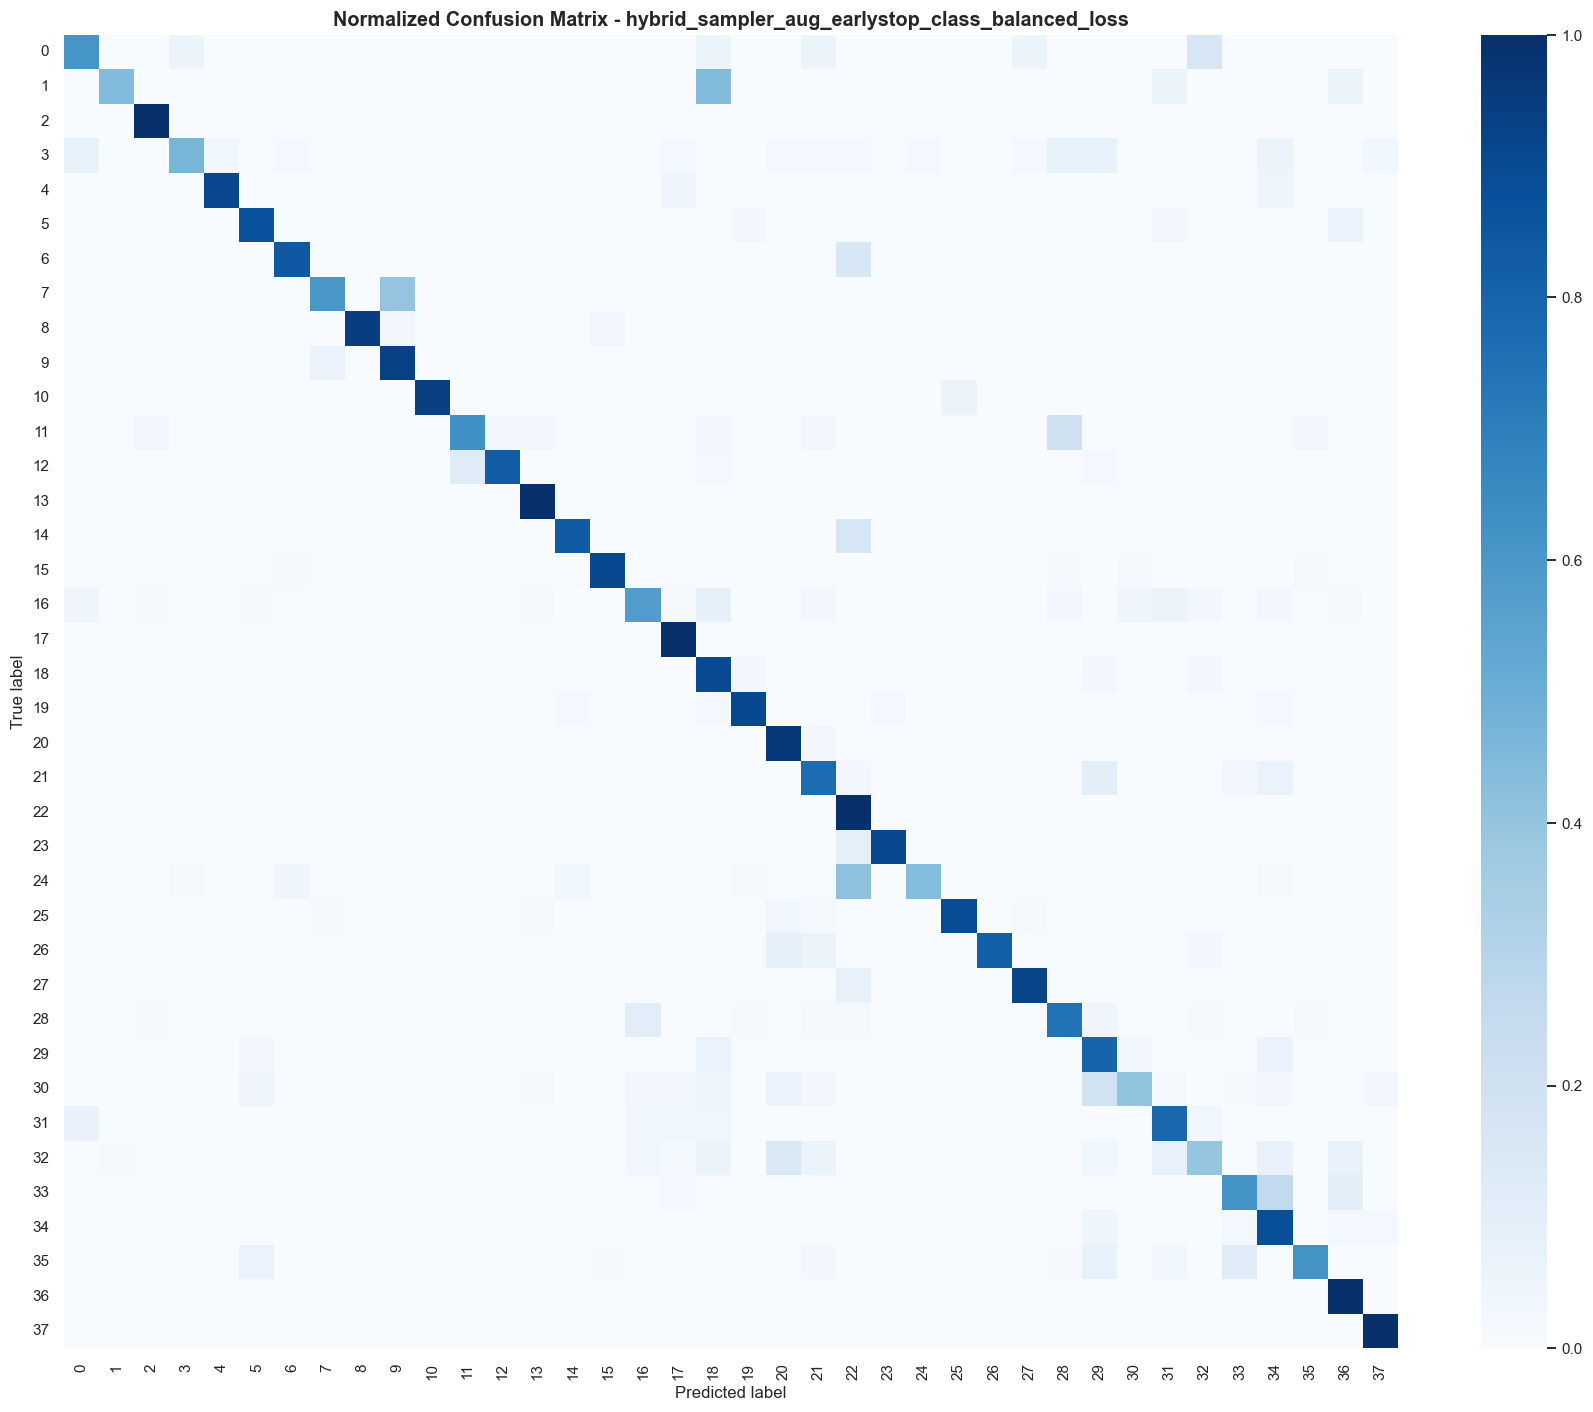

array([[0.61111111, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.44444444, 0.        , ..., 0.        , 0.05555556,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.61875   , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]], shape=(38, 38))

In [8]:
hybrid_per_class_df = pd.DataFrame({
    'Experiment': hybrid_name,
    'Class_ID': range(NUM_CLASSES),
    'Class': class_names_list,
    'Train Sample Count': [int(train_counts.get(class_id, 0)) for class_id in range(NUM_CLASSES)],
    'Is Minority': [class_id in minority_ids for class_id in range(NUM_CLASSES)],
    'Precision': hybrid_result['per_class_precision'],
    'Recall': hybrid_result['per_class_recall'],
    'F1-score': hybrid_result['per_class_f1'],
})

hybrid_per_class_df.to_csv(PHASE07_TABLE_DIR / f'{hybrid_name}_per_class_metrics.csv', index=False)
display(hybrid_per_class_df.head(10))

plot_confusion_heatmap(
    hybrid_result['labels'],
    hybrid_result['preds'],
    labels=list(range(NUM_CLASSES)),
    normalize='true',
    title=f'Normalized Confusion Matrix - {hybrid_name}',
    save_path=PHASE07_FIGURE_DIR / f'{hybrid_name}_confusion_matrix_normalized.png',
    figsize=(16, 13),
)


# 09. So sánh hybrid với hai winner đơn lẻ

Bảng này trả lời câu hỏi chính: kết hợp có hơn Phase 05 winner và Phase 06 winner không?

In [9]:
hybrid_summary = {
    'Experiment': hybrid_name,
    'Source': 'Phase 07 Hybrid',
    'Strategy': f'{phase05_winner_name} + {phase06_winner_name}',
    'Accuracy': hybrid_result['accuracy'],
    'Macro Precision': hybrid_result['precision'],
    'Macro Recall': hybrid_result['recall'],
    'Macro F1': hybrid_result['macro_f1'],
    'Minority Recall': np.mean([hybrid_result['per_class_recall'][class_id] for class_id in minority_ids]),
    'Worst Recall': np.min(hybrid_result['per_class_recall']),
}

phase05_compare = phase05_winner.to_dict()
phase05_compare['Source'] = 'Phase 05 Winner'
phase05_compare['Strategy'] = phase05_winner_name

phase06_compare = phase06_winner.to_dict()
phase06_compare['Source'] = 'Phase 06 Winner'
phase06_compare['Strategy'] = phase06_winner_name

comparison_df = pd.DataFrame([phase05_compare, phase06_compare, hybrid_summary])
comparison_df = comparison_df[[
    'Source', 'Experiment', 'Strategy',
    'Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Minority Recall', 'Worst Recall',
]]
comparison_df = comparison_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
comparison_df.to_csv(PHASE07_TABLE_DIR / 'phase07_hybrid_strategy_comparison.csv', index=False)

display(comparison_df)

hybrid_delta_macro_f1_vs_phase05 = hybrid_summary['Macro F1'] - float(phase05_winner['Macro F1'])
hybrid_delta_macro_f1_vs_phase06 = hybrid_summary['Macro F1'] - float(phase06_winner['Macro F1'])
print(f"Δ Macro F1 vs Phase 05 winner: {hybrid_delta_macro_f1_vs_phase05:+.4f}")
print(f"Δ Macro F1 vs Phase 06 winner: {hybrid_delta_macro_f1_vs_phase06:+.4f}")


,Source,Experiment,Strategy,Accuracy,Macro Precision,Macro Recall,Macro F1,Minority Recall,Worst Recall
0,Phase 05 Winner,sampler_aug_earlystop,sampler_aug_earlystop,0.833127,NaN,NaN,0.812635,0.898826,0.522727
1,Phase 06 Winner,class_balanced_loss,class_balanced_loss,0.832509,0.775059,0.845858,0.795935,0.886295,0.452830
2,Phase 07 Hybrid,hybrid_sampler_aug_earlystop_class_balanced_loss,sampler_aug_earlystop + class_balanced_loss,0.736712,0.735455,0.792523,0.727835,0.891028,0.396226


Δ Macro F1 vs Phase 05 winner: -0.0848
Δ Macro F1 vs Phase 06 winner: -0.0681


# 10. Visualization

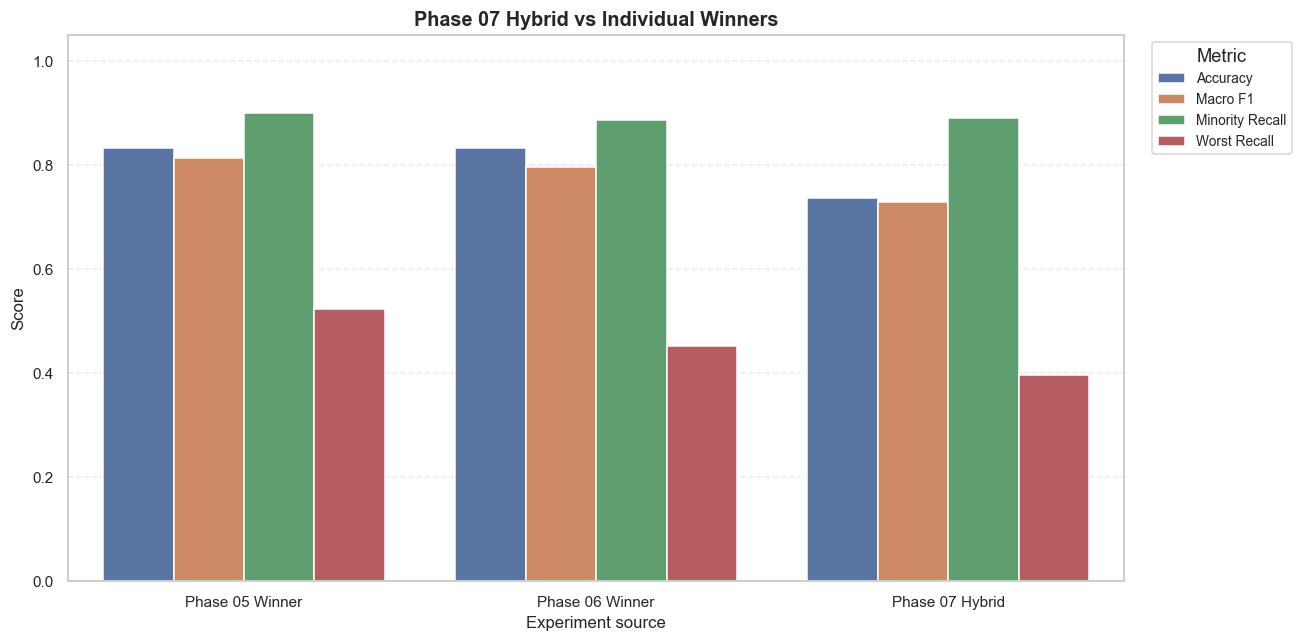

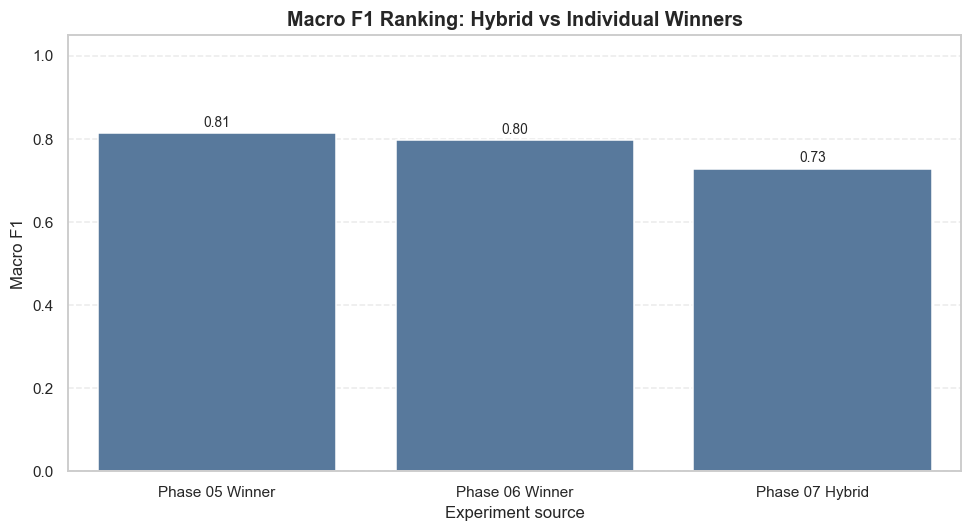

In [10]:
plot_df = comparison_df.melt(
    id_vars=['Source', 'Experiment'],
    value_vars=['Accuracy', 'Macro F1', 'Minority Recall', 'Worst Recall'],
    var_name='Metric',
    value_name='Score',
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x='Source', y='Score', hue='Metric')
ax.set_title('Phase 07 Hybrid vs Individual Winners', fontweight='bold')
ax.set_xlabel('Experiment source')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PHASE07_FIGURE_DIR / 'phase07_hybrid_vs_winners.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
rank_df = comparison_df.sort_values('Macro F1', ascending=False)
ax = sns.barplot(data=rank_df, x='Source', y='Macro F1', color='#4C78A8')
ax.set_title('Macro F1 Ranking: Hybrid vs Individual Winners', fontweight='bold')
ax.set_xlabel('Experiment source')
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.4)
annotate_bars(ax)
plt.tight_layout()
plt.savefig(PHASE07_FIGURE_DIR / 'phase07_macro_f1_ranking.png', dpi=300, bbox_inches='tight')
plt.show()


# 11. Interpretation và report export

In [11]:
best_row = comparison_df.sort_values('Macro F1', ascending=False).iloc[0]

if best_row['Source'] == 'Phase 07 Hybrid':
    conclusion = 'Hybrid strategy cải thiện Macro F1 so với các hướng đơn lẻ, cho thấy sampler/data-level balancing và loss-level balancing có hiệu ứng bổ trợ.'
else:
    conclusion = 'Hybrid strategy không vượt winner đơn lẻ. Điều này cho thấy một hướng imbalance handling đã đủ mạnh hoặc việc kết hợp làm optimization kém ổn định hơn.'

interpretation = f"""
PHASE 07 INTERPRETATION
=======================

Phase 07 kiểm tra hybrid strategy bằng SimpleCNN: kết hợp winner của Phase 05 (`{phase05_winner_name}`) với winner của Phase 06 (`{phase06_winner_name}`).

Kết quả so sánh:
- Hybrid ΔMacro F1 so với Phase 05 winner: {hybrid_delta_macro_f1_vs_phase05:+.4f}
- Hybrid ΔMacro F1 so với Phase 06 winner: {hybrid_delta_macro_f1_vs_phase06:+.4f}

Experiment tốt nhất theo Macro F1 là `{best_row['Experiment']}` từ `{best_row['Source']}` với Macro F1 = {best_row['Macro F1']:.4f}.

{conclusion}

Phase 07 vẫn thuộc giai đoạn SimpleCNN. Từ Phase 08 trở đi mới bắt đầu huấn luyện các mô hình học sâu hiện đại như MobileNetV2 và EfficientNet-B0.
""".strip()

report_sections = []
report_sections.append('# Phase 07 Report: SimpleCNN Hybrid Strategy Study')
report_sections.append('')
report_sections.append('## 1. Hybrid design')
report_sections.append(dataframe_to_markdown_safe(hybrid_design_df))
report_sections.append('')
report_sections.append('## 2. Hybrid vs individual winners')
report_sections.append(dataframe_to_markdown_safe(comparison_df))
report_sections.append('')
report_sections.append('## 3. Interpretation')
report_sections.append(interpretation)

write_text_report(PHASE07_REPORT_DIR / 'phase07_simplecnn_hybrid_strategy_report.md', report_sections)
write_text_report(PHASE07_REPORT_DIR / 'phase07_simplecnn_hybrid_strategy_report.txt', report_sections)
write_text_report(PHASE07_REPORT_DIR / 'phase07_simplecnn_hybrid_interpretation.txt', [interpretation])

print('\n'.join(report_sections))


# Phase 07 Report: SimpleCNN Hybrid Strategy Study

## 1. Hybrid design
                               Hybrid Experiment    Phase 05 Component                                       Phase 05 Description  Phase 06 Component  Train Size  Use Sampler  Use EarlyStopping
hybrid_sampler_aug_earlystop_class_balanced_loss sampler_aug_earlystop WeightedRandomSampler + Light Augmentation + EarlyStopping class_balanced_loss        9383         True               True

## 2. Hybrid vs individual winners
         Source                                       Experiment                                    Strategy  Accuracy  Macro Precision  Macro Recall  Macro F1  Minority Recall  Worst Recall
Phase 05 Winner                            sampler_aug_earlystop                       sampler_aug_earlystop  0.833127              NaN           NaN  0.812635         0.898826      0.522727
Phase 06 Winner                              class_balanced_loss                         class_balanced_loss  0.832509    